Cas α = 0.5 et tol = 10^-3


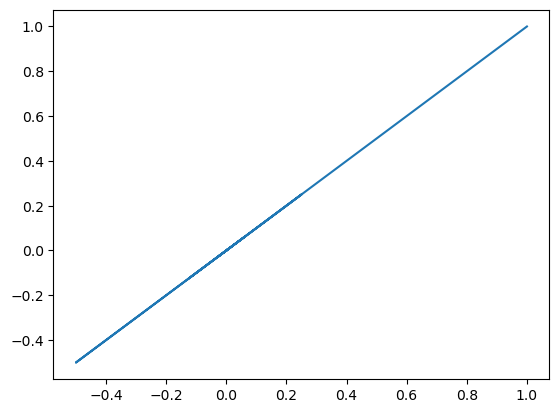

Nombre d'itérations : 13
Temps d'exécution : 0.0018076896667480469 secondes

Cas α = 0.5 et tol = 10^-5


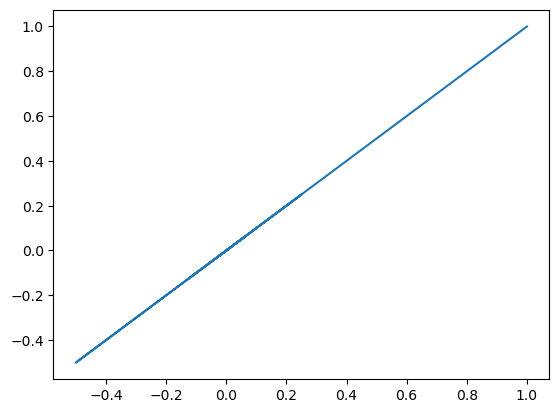

Nombre d'itérations : 19
Temps d'exécution : 0.0003345012664794922 secondes


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import time

def minimaLocaux(x, y):
    return x**2 + x*y + y**2

def gradient_minimaLocaux(x, y):
    dfdx = 2*x + y
    dfdy = x + 2*y
    return np.array([dfdx, dfdy])

def gradient_pas_fixe(x, y, tol=1e-3, h=1, tmax=100):
    x, y = float(x), float(y)

    xs = [x]
    ys = [y]

    debut = time.time()

    for k in range(tmax):

        g = gradient_minimaLocaux(x, y)

        if np.sqrt(g[0]**2 + g[1]**2) < tol:
            break

        x = x - h * g[0]
        y = y - h * g[1]

        xs.append(x)
        ys.append(y)

    fin = time.time()

    plt.plot(xs, ys)
    plt.show()

    print("Nombre d'itérations :", k)
    print("Temps d'exécution :", fin - debut, "secondes")

    return x, y, k, fin - debut

print("Cas α = 0.5 et tol = 10^-3")
x, y, k, t = gradient_pas_fixe(1, 1, tol=1e-3, h=0.5, tmax=300)

print("\nCas α = 0.5 et tol = 10^-5")
x, y, k, t = gradient_pas_fixe(1, 1, tol=1e-5, h=0.5, tmax=300)

========== alpha = 1 ==========
     k                                                 xk  \
0    0                                         [1.0, 1.0]   
1    1                                       [-2.0, -2.0]   
2    2                                         [4.0, 4.0]   
3    3                                       [-8.0, -8.0]   
4    4                                       [16.0, 16.0]   
..  ..                                                ...   
95  95   [-3.961408125713217e+28, -3.961408125713217e+28]   
96  96     [7.922816251426434e+28, 7.922816251426434e+28]   
97  97  [-1.5845632502852868e+29, -1.5845632502852868e...   
98  98   [3.1691265005705735e+29, 3.1691265005705735e+29]   
99  99   [-6.338253001141147e+29, -6.338253001141147e+29]   

                                                 xk+1        ||dk||  \
0                                        [-2.0, -2.0]  4.242641e+00   
1                                          [4.0, 4.0]  8.485281e+00   
2                     

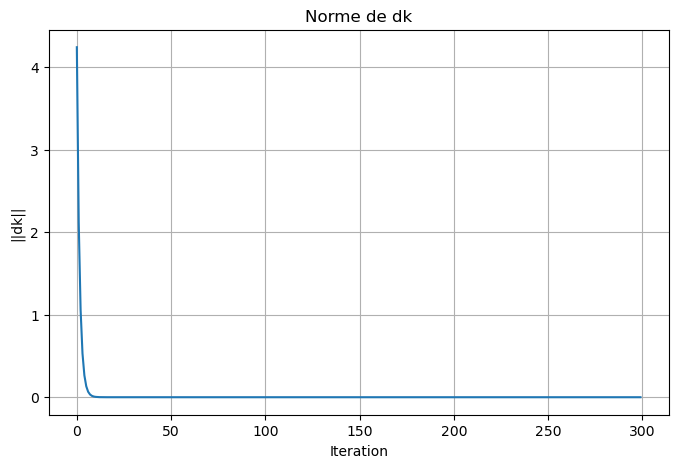

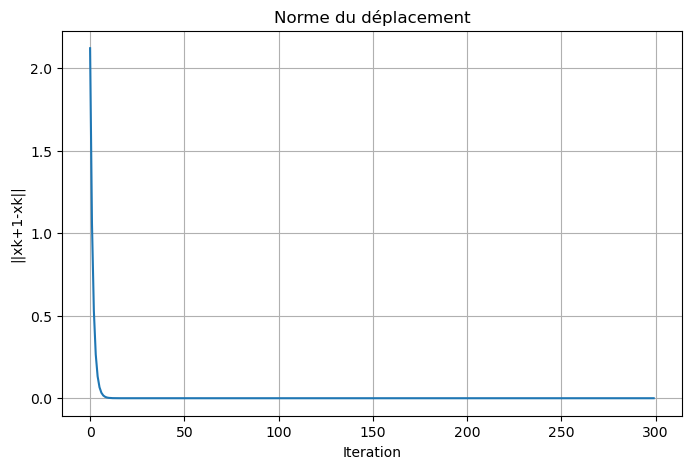

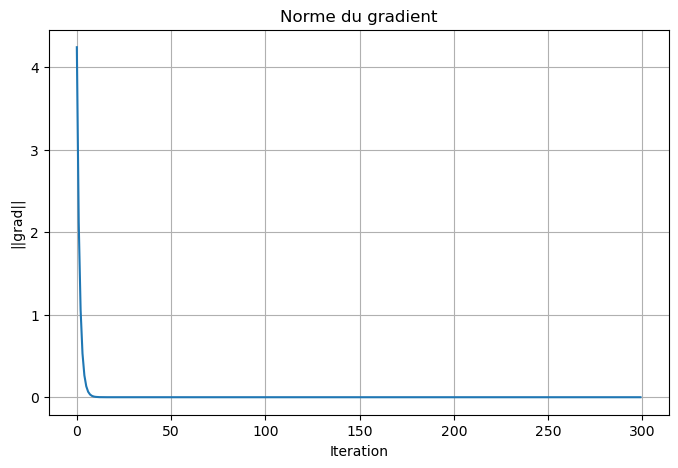

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# ==========================================================
# Fonction
# f(x1,x2) = x1² + x1*x2 + x2²
# ==========================================================

def f(x):
    return x[0]**2 + x[0]*x[1] + x[1]**2


# ==========================================================
# Gradient
# ∇f(x) = (2x1+x2 , x1+2x2)
# ==========================================================

def gradient(x):
    return np.array([
        2*x[0] + x[1],
        x[0] + 2*x[1]
    ])


# ==========================================================
# Méthode du gradient
# ==========================================================

def gradient_method(x0, alpha, iterations):

    x = np.array(x0, dtype=float)

    resultats = []

    debut = time.time()

    for k in range(iterations):

        grad = gradient(x)

        d = -grad

        x_new = x + alpha*d

        resultats.append([
            k,
            x.copy(),
            x_new.copy(),
            np.linalg.norm(d),
            np.linalg.norm(x_new-x),
            np.linalg.norm(grad)
        ])

        x = x_new

    fin = time.time()

    temps = fin - debut

    return resultats, temps


# ==========================================================
# Point initial
# ==========================================================

x0 = [1,1]


# ==========================================================
# Cas 1 : alpha = 1
# ==========================================================

resultats1, temps1 = gradient_method(x0,1,100)


# ==========================================================
# Cas 2 : alpha = 0.5
# ==========================================================

resultats2, temps2 = gradient_method(x0,0.5,300)


# ==========================================================
# Tableau des résultats
# ==========================================================

colonnes = [
    "k",
    "xk",
    "xk+1",
    "||dk||",
    "||xk+1-xk||",
    "||grad||"
]

df1 = pd.DataFrame(resultats1,columns=colonnes)
df2 = pd.DataFrame(resultats2,columns=colonnes)

print("========== alpha = 1 ==========")
print(df1)

print()

print("Temps :",temps1,"secondes")

print()

print("========== alpha = 0.5 ==========")
print(df2)

print()

print("Temps :",temps2,"secondes")


# ==========================================================
# Graphique 1
# ||dk||
# ==========================================================

plt.figure(figsize=(8,5))
plt.plot(df2["||dk||"])
plt.title("Norme de dk")
plt.xlabel("Iteration")
plt.ylabel("||dk||")
plt.grid()
plt.show()


# ==========================================================
# Graphique 2
# ||xk+1-xk||
# ==========================================================

plt.figure(figsize=(8,5))
plt.plot(df2["||xk+1-xk||"])
plt.title("Norme du déplacement")
plt.xlabel("Iteration")
plt.ylabel("||xk+1-xk||")
plt.grid()
plt.show()


# ==========================================================
# Graphique 3
# ||grad||
# ==========================================================

plt.figure(figsize=(8,5))
plt.plot(df2["||grad||"])
plt.title("Norme du gradient")
plt.xlabel("Iteration")
plt.ylabel("||grad||")
plt.grid()
plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import time


def f(x):
    return x[0]**2 + x[0]*x[1] + x[1]**2



def gradient(x):
    return np.array([
        2*x[0] + x[1],
        x[0] + 2*x[1]
    ])



def gradient_method(x0, alpha, iterations):

    x = np.array(x0, dtype=float)

    resultats = []

    debut = time.time()

    for k in range(iterations):

        grad = gradient(x)

        d = -grad

        x_new = x + alpha*d

        resultats.append([
            k,
            x.copy(),
            x_new.copy(),
            np.linalg.norm(d),
            np.linalg.norm(x_new-x),
            np.linalg.norm(grad)
        ])

        x = x_new

    fin = time.time()

    temps = fin - debut

    return resultats, temps

x0 = [1,1]

resultats1, temps1 = gradient_method(x0,1,100)
print(temps1)
resultats2, temps2 = gradient_method(x0,0.5,300)
print(temps2)


0.008584737777709961
0.022719383239746094
